In [6]:
#1
import pandas as pd
df = pd.read_csv("atus_00001.csv", low_memory=False)
print(df)

        YEAR          CASEID  SERIAL  STRATA  PERNUM  LINENO          WT06  \
0       2004  20040101040003       1   100.0       1       1  3.158614e+06   
1       2004  20040101040003       1   100.0       1       1  3.158614e+06   
2       2004  20040101040003       1   100.0       1       1  3.158614e+06   
3       2004  20040101040003       1   100.0       1       1  3.158614e+06   
4       2004  20040101040003       1   100.0       1       1  3.158614e+06   
...      ...             ...     ...     ...     ...     ...           ...   
418572  2024  20241212242303    7669     NaN       1       1  1.527989e+07   
418573  2024  20241212242303    7669     NaN       1       1  1.527989e+07   
418574  2024  20241212242303    7669     NaN       1       1  1.527989e+07   
418575  2024  20241212242303    7669     NaN       1       1  1.527989e+07   
418576  2024  20241212242303    7669     NaN       1       1  1.527989e+07   

        ACTIVITY  WHERE  DURATION  
0          10101   9999    

In [ ]:
#2: There are 418,577 rows and 10 columns

In [ ]:
#3: Everything looks correct so far

In [15]:
#4
cols_to_drop = ["CASEID", "SERIAL", "STRATA", "PERNUM", "LINENO", "WT06"]
df = df.drop(columns=cols_to_drop)
df.head()

,YEAR,ACTIVITY,WHERE,DURATION
0,2004,10101,9999,390
1,2004,10201,9999,90
2,2004,180701,230,20
3,2004,70101,106,40
4,2004,180701,230,20


In [16]:
print(df)

        YEAR  ACTIVITY  WHERE  DURATION
0       2004     10101   9999       390
1       2004     10201   9999        90
2       2004    180701    230        20
3       2004     70101    106        40
4       2004    180701    230        20
...      ...       ...    ...       ...
418572  2024    180209    230        10
418573  2024     20201    101        15
418574  2024    110101    101        30
418575  2024    120303    101       270
418576  2024     10101   9999       408

[418577 rows x 4 columns]


In [17]:
df = df.rename(columns={
    "YEAR": "year",
    "ACTIVITY": "activity_code",
    "WHERE": "location_code",
    "DURATION": "minutes"
})

In [16]:
df.head()
df.dtypes

year             int64
activity_code    int64
location_code    int64
minutes          int64
dtype: object

In [18]:
print(df)

        year  activity_code  location_code  minutes
0       2004          10101           9999      390
1       2004          10201           9999       90
2       2004         180701            230       20
3       2004          70101            106       40
4       2004         180701            230       20
...      ...            ...            ...      ...
418572  2024         180209            230       10
418573  2024          20201            101       15
418574  2024         110101            101       30
418575  2024         120303            101      270
418576  2024          10101           9999      408

[418577 rows x 4 columns]


In [19]:
#5a: The calendar year in which the ATUS activity diary was collected
df["year"].describe()
df["year"].dtype

#ATUS activity classification code identifying what the respondent was doing
df["activity_code"].describe()
df["activity_code"].dtype

#Where the activity took place
df["location_code"].describe()
df["location_code"].dtype

#Duration of activity in minutes
df["minutes"].describe()
df["minutes"].dtype

dtype('int64')

In [20]:
#5b: All variables in the dataset are stored as numeric integers (int64). 
#The year variable correctly represents the survey year. 
#The activity_code and location_code variables are categorical identifiers but are stored as integers for analytical purposes. 
#The minutes variable measures the duration of activities in minutes and is stored as an integer. 
#No data type corrections were required at this stage.

In [21]:
#5c
df["year"].min(), df["year"].max()

(2004, 2024)

In [22]:
df["activity_code"].min(), df["activity_code"].max()

(10101, 509999)

In [23]:
df["activity_code"].nunique()
df["activity_code"].mode()

0    10101
Name: activity_code, dtype: int64

In [24]:
df["location_code"].min(), df["location_code"].max()

(101, 9999)

In [25]:
df["minutes"].min(), df["minutes"].max()

(1, 1310)

In [26]:
df["minutes"].describe()

count    418577.000000
mean         74.453398
std          99.906094
min           1.000000
25%          15.000000
50%          30.000000
75%          90.000000
max        1310.000000
Name: minutes, dtype: float64

In [27]:
#5d: There were no missing values in any column.
df["year"].isna().sum()

0

In [28]:
df["activity_code"].isna().sum()

0

In [45]:
df["location_code"].isna().sum()

0

In [46]:
df["minutes"].isna().sum()

0

In [47]:
#6: The question for my project was the following: 
#How has increased access to digital technology affected individuals’ allocation of time between 
in-person social interaction and screen-based activities in the United States?
#After excluding the unnecessary columns, the new columns should provide a clearer picture of the activity, 
where it took place, and how long it lasted. I am still debating on keeping the "location_code" column since there 
aren't many variables, and it could be deemed unnecessary to the research question. 
#Another research question I can dig deeper into is: How increased access to streaming services affected how 
much time individuals spend playing sports vs watching them over the last 20 years? This question would require
data cleaning to include sports-related activities specifically.
#One more research question can be: How has globalization affected individuals' possibility to travel over the last 20 years?
For this, I would need to specifically look at activity codes that include travel, and the "location_code" column
might be necessary here.

In [ ]:
#7: I completed this in a previous step and may look into including more necessary columns, or excluding 
the "location_code" column as stated previously. 

In [ ]:
#8: For my first research question, I can use regression analysis to 
estimate how time allocation changes as technology use increases.
#For my second research question, I can use ANOVA analysis since there are two 
outcome groups to test whether average time differs across time periods.
#For my third research question, I can use regression analysis to examine trends in travel behavior over time.

In [ ]:
#Project Assignment 2

In [61]:
#Data cleaning and preparation
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418577 entries, 0 to 418576
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   year           418577 non-null  int64
 1   activity_code  418577 non-null  int64
 2   minutes        418577 non-null  int64
dtypes: int64(3)
memory usage: 9.6 MB


,year,activity_code,minutes
count,418577.000000,418577.000000,418577.000000
mean,2010.667113,88111.673300,74.453398
std,9.428259,73490.573025,99.906094
min,2004.000000,10101.000000,1.000000
25%,2004.000000,20201.000000,15.000000
50%,2004.000000,110101.000000,30.000000
75%,2024.000000,120312.000000,90.000000
max,2024.000000,509999.000000,1310.000000


In [50]:
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={
    "activity": "activity_code",
    "where": "location_code",
    "duration": "minutes"
})

In [54]:
df.info()
df["minutes"].min(), df["minutes"].max()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418577 entries, 0 to 418576
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   year           418577 non-null  int64
 1   activity_code  418577 non-null  int64
 2   location_code  418577 non-null  int64
 3   minutes        418577 non-null  int64
dtypes: int64(4)
memory usage: 12.8 MB


(1, 1310)

In [ ]:
df = df.drop(columns=["location_code"])

In [60]:
print(df)

        year  activity_code  minutes
0       2004          10101      390
1       2004          10201       90
2       2004         180701       20
3       2004          70101       40
4       2004         180701       20
...      ...            ...      ...
418572  2024         180209       10
418573  2024          20201       15
418574  2024         110101       30
418575  2024         120303      270
418576  2024          10101      408

[418577 rows x 3 columns]


In [62]:
#Handling missing data
df.isna().sum()

year             0
activity_code    0
minutes          0
dtype: int64

In [63]:
df["year"].value_counts().sort_index().head()

year
2004    279042
2024    139535
Name: count, dtype: int64

In [64]:
(df["minutes"] <= 0).sum()

0

In [65]:
df["activity_code"].min(), df["activity_code"].max()

(10101, 509999)

In [ ]:
#So far, all the data looks clean and makes sense, while there are no missing values.

In [66]:
#Data Transformations
def classify_activity(code):
    # Screen-based
    if code in [120303, 120304, 120307, 120308] or str(code).startswith("1601"):
        return "screen"
    
    # In-person social
    elif code in [120101, 120201, 120202]:
        return "social"
    
    else:
        return "other"

df["activity_type"] = df["activity_code"].apply(classify_activity)

In [67]:
df["activity_type"].value_counts()

activity_type
other     363125
screen     42689
social     12763
Name: count, dtype: int64

In [ ]:
#From this point, I wanted to incorporate leisure activities that didn't involve screens and see how that
has changed over twenty years. For this, I needed to change up my first research question, and decided 
to go with: How has increased access to digital technology altered the allocation of time between screen-based 
activities, traditional leisure activities, and in-person social interaction over the last 20 years? 
This way, I can incorporate in-person social activites with non-digital leisure activities.  

In [68]:
def classify_activity(code):
    
    # Strict screen
    if code in [120303, 120304, 120307, 120308] or str(code).startswith("1601"):
        return "screen"
    
    # Social interaction
    elif code in [120101, 120201, 120202]:
        return "social"
    
    # Non-screen leisure
    elif code in [120305, 120306, 120309, 120310, 120311, 120312, 120313]:
        return "non_screen_leisure"
    
    else:
        return "other"

df["activity_type"] = df["activity_code"].apply(classify_activity)

In [69]:
df["activity_type"].value_counts()

activity_type
other                 353083
screen                 42689
social                 12763
non_screen_leisure     10042
Name: count, dtype: int64

In [57]:
df_yearly = df.groupby(["year", "activity_type"])["minutes"].sum().reset_index()
df_yearly.head()

,year,activity_type,minutes
0,2003,non_screen_leisure,621450
1,2003,other,24347697
2,2003,screen,3784673
3,2003,social,1082980
4,2004,non_screen_leisure,466860


In [58]:
df_pivot = df_yearly.pivot(index="year",
                           columns="activity_type",
                           values="minutes").reset_index()
df_pivot = df_pivot.fillna(0)
print(df)

         year  activity_code  minutes activity_type
0        2003         130124       60         other
1        2003          10201       30         other
2        2003          10101      600         other
3        2003         120303      150        screen
4        2003         110101        5         other
...       ...            ...      ...           ...
4880016  2024         180209       10         other
4880017  2024          20201       15         other
4880018  2024         110101       30         other
4880019  2024         120303      270        screen
4880020  2024          10101      408         other

[4880021 rows x 4 columns]


In [59]:
df_yearly.groupby("year")["activity_type"].count()

year
2003    4
2004    4
2005    4
2006    4
2007    4
2008    4
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    4
2024    4
Name: activity_type, dtype: int64

In [60]:
df_pivot["total_minutes"] = (
    df_pivot["screen"] +
    df_pivot["social"] +
    df_pivot["non_screen_leisure"] +
    df_pivot["other"]
)

In [61]:
df_pivot["screen_share"] = df_pivot["screen"] / df_pivot["total_minutes"]
df_pivot["social_share"] = df_pivot["social"] / df_pivot["total_minutes"]
df_pivot["non_screen_share"] = df_pivot["non_screen_leisure"] / df_pivot["total_minutes"]

In [62]:
df_pivot.head()

activity_type,year,non_screen_leisure,other,screen,social,total_minutes,screen_share,social_share,non_screen_share
0,2003,621450,24347697,3784673,1082980,29836800,0.126846,0.036297,0.020828
1,2004,466860,16282349,2665267,706644,20121120,0.132461,0.035120,0.023202
2,2005,407468,15320680,2394252,652320,18774720,0.127525,0.034745,0.021703
3,2006,389402,15169390,2435066,644062,18637920,0.130651,0.034557,0.020893
4,2007,348594,14365644,2327565,595317,17637120,0.131970,0.033754,0.019765


In [63]:
df["year"].value_counts().sort_index()

year
2003    412611
2004    279042
2005    263099
2006    263286
2007    238415
2008    253608
2009    261307
2010    257193
2011    234358
2012    230920
2013    215576
2014    223249
2015    214429
2016    207213
2017    199894
2018    184103
2019    182980
2020    155109
2021    164581
2022    146393
2023    153120
2024    139535
Name: count, dtype: int64

In [ ]:
#Project Assignment 3

In [ ]:
#Processing Strings

In [64]:
df["activity_type"].unique()

array(['other', 'screen', 'social', 'non_screen_leisure'], dtype=object)

In [65]:
df["activity_type"] = df["activity_type"].str.strip().str.lower()

In [66]:
df["activity_type"] = df["activity_type"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880021 entries, 0 to 4880020
Data columns (total 4 columns):
 #   Column         Dtype   
---  ------         -----   
 0   year           int64   
 1   activity_code  int64   
 2   minutes        int64   
 3   activity_type  category
dtypes: category(1), int64(3)
memory usage: 116.3 MB


In [67]:
df.select_dtypes(include="object")

""
0
1
2
3
4
...
4880016
4880017
4880018
4880019


In [69]:
#Data Wrangling: Combining and Merging Datasets
#Based on my dataset, I don't find it necessary to merge further data sets, as the 
#ATUS data set provides all the variables I need to further answer both of my research questions. 

In [ ]:
#Data Wrangling: Reshaping and Pivoting

In [86]:
df_pivot = df_yearly.pivot(index="year",
                           columns="activity_type",
                           values="minutes").reset_index()
print(df_pivot)

activity_type  year  non_screen_leisure     other   screen  social
0              2004              466860  16282349  2665267  706644
1              2024              229481   8817428  1686988  309463


In [88]:
df_pivot.head()

activity_type,year,non_screen_leisure,other,screen,social
0,2004,466860,16282349,2665267,706644
1,2024,229481,8817428,1686988,309463


In [89]:
df_pivot.shape

(2, 5)

In [90]:
df["year"].unique()

array([2004, 2024])

In [ ]:
#From this point, I will be considering going beyond just two years of data and possibly
looking at years within these two, as this will bring more trends of increased use
of technology throughout the years. I will go back to ATUS and download all the data to 
provide a more time-series-based analysis. 

In [ ]:
#Project Assignment 4

In [70]:
pd.read_csv("atus_00002.csv")

,YEAR,ACTIVITY,DURATION
0,2003,130124,60
1,2003,10201,30
2,2003,10101,600
3,2003,120303,150
4,2003,110101,5
...,...,...,...
4880016,2024,180209,10
4880017,2024,20201,15
4880018,2024,110101,30
4880019,2024,120303,270


In [78]:
df_full.columns

Index(['YEAR', 'ACTIVITY', 'DURATION'], dtype='object')

In [79]:
df_full = pd.read_csv("atus_00002.csv", sep=",", encoding="latin1", engine="python")

In [80]:
df_full.columns

Index(['YEAR', 'ACTIVITY', 'DURATION'], dtype='object')

In [74]:
df_full.head()

,YEAR,ACTIVITY,DURATION
0,2003,130124,60
1,2003,10201,30
2,2003,10101,600
3,2003,120303,150
4,2003,110101,5


In [75]:
df_full["YEAR"].dtype

dtype('int64')

In [76]:
df_full = df_full[df_full["YEAR"] != 2003]

In [21]:
df_full["YEAR"].min()

2004

In [22]:
df_full["YEAR"].unique()

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [81]:
df_full = df_full.rename(columns={
    "YEAR": "year",
    "ACTIVITY": "activity_code",
    "DURATION": "minutes"
})
df_full.columns

Index(['year', 'activity_code', 'minutes'], dtype='object')

In [82]:
def classify_activity(code):

    #Strict screen
    if code in [120303, 120304, 120307, 120308] or str(code).startswith("1601"):
        return "screen"

    #Social interaction
    elif code in [120101, 120201, 120202]:
        return "social"

    # on-screen leisure
    elif code in [120305, 120306, 120309, 120310, 120311, 120312, 120313]:
        return "non_screen_leisure"

    else:
        return "other"

df_full["activity_type"] = df_full["activity_code"].apply(classify_activity)

In [83]:
df_full["activity_type"] = df_full["activity_type"].astype("category")
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880021 entries, 0 to 4880020
Data columns (total 4 columns):
 #   Column         Dtype   
---  ------         -----   
 0   year           int64   
 1   activity_code  int64   
 2   minutes        int64   
 3   activity_type  category
dtypes: category(1), int64(3)
memory usage: 116.3 MB


In [84]:
df_pivot = df_yearly.pivot(index="year",
                           columns="activity_type",
                           values="minutes").reset_index()

df_pivot = df_pivot.fillna(0)

In [85]:
df_pivot.shape

(22, 5)

In [86]:
df_pivot.head()

activity_type,year,non_screen_leisure,other,screen,social
0,2003,621450,24347697,3784673,1082980
1,2004,466860,16282349,2665267,706644
2,2005,407468,15320680,2394252,652320
3,2006,389402,15169390,2435066,644062
4,2007,348594,14365644,2327565,595317


In [ ]:
#Now that I have included years between 2004 and 2024, I can proceed with further analysis 
on the difference technology has made to scree time, social activities, and non-screen leisure time.

In [87]:
#Research Question 1: Histograms
df_pivot["total_minutes"] = (
    df_pivot["screen"] +
    df_pivot["social"] +
    df_pivot["non_screen_leisure"] +
    df_pivot["other"]
)

df_pivot["screen_share"] = df_pivot["screen"] / df_pivot["total_minutes"]
df_pivot["social_share"] = df_pivot["social"] / df_pivot["total_minutes"]
df_pivot["non_screen_share"] = df_pivot["non_screen_leisure"] / df_pivot["total_minutes"]

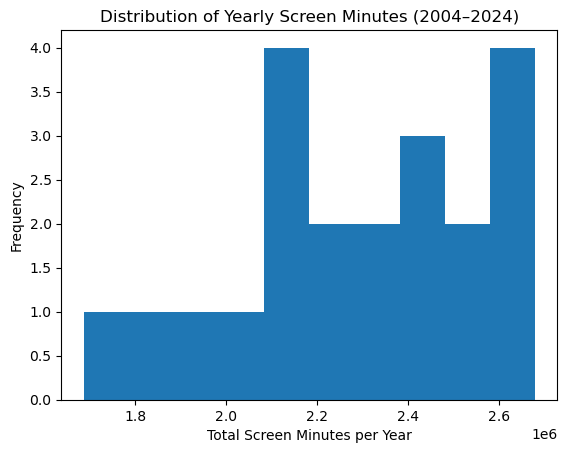

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(df_pivot["screen"], bins=10)

plt.xlabel("Total Screen Minutes per Year")
plt.ylabel("Frequency")
plt.title("Distribution of Yearly Screen Minutes (2004–2024)")

plt.show()

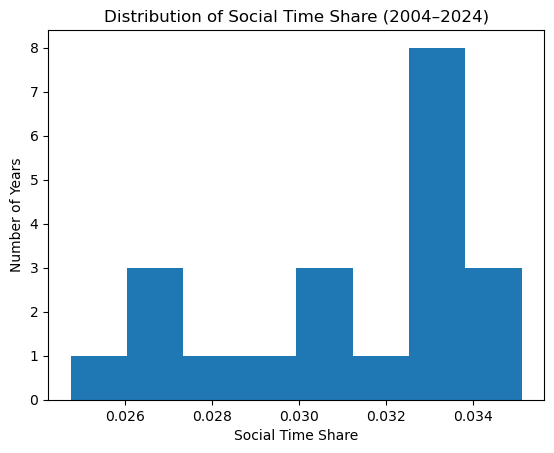

In [33]:
plt.figure()

plt.hist(df_pivot["social_share"], bins=8)

plt.xlabel("Social Time Share")
plt.ylabel("Number of Years")
plt.title("Distribution of Social Time Share (2004–2024)")

plt.show()

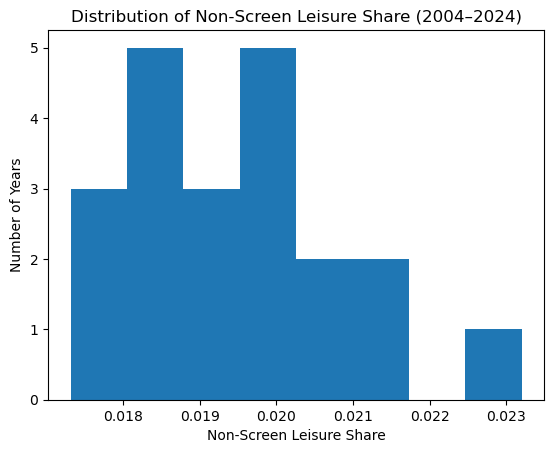

In [34]:
plt.figure()

plt.hist(df_pivot["non_screen_share"], bins=8)

plt.xlabel("Non-Screen Leisure Share")
plt.ylabel("Number of Years")
plt.title("Distribution of Non-Screen Leisure Share (2004–2024)")

plt.show()

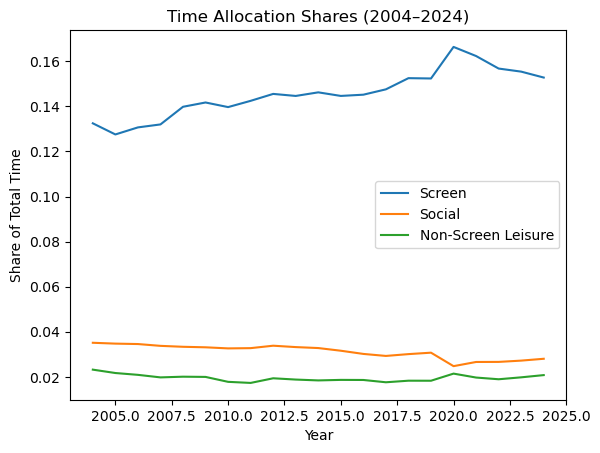

In [36]:
#Line plot
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df_pivot["year"], df_pivot["screen_share"])
plt.plot(df_pivot["year"], df_pivot["social_share"])
plt.plot(df_pivot["year"], df_pivot["non_screen_share"])

plt.xlabel("Year")
plt.ylabel("Share of Total Time")
plt.title("Time Allocation Shares (2004–2024)")

plt.legend(["Screen", "Social", "Non-Screen Leisure"])

plt.show()

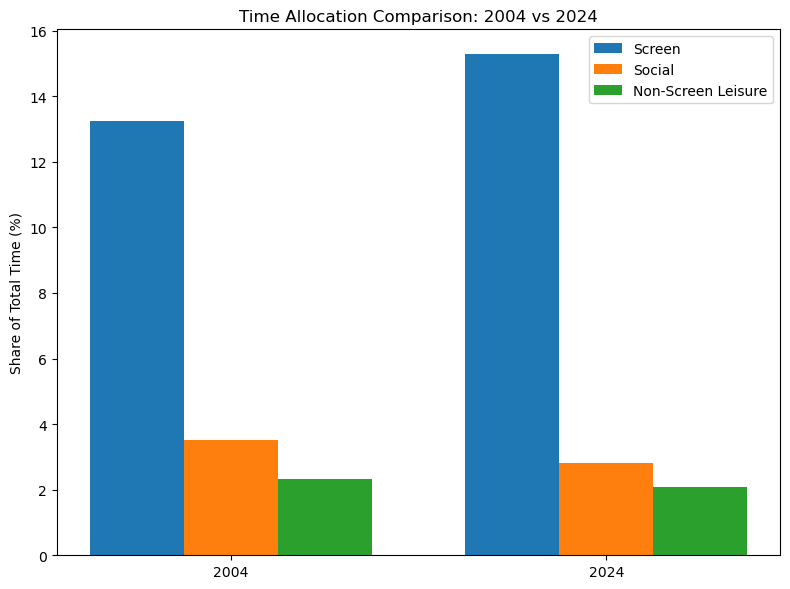

In [42]:
#Bar Chart
import numpy as np

df_compare = df_pivot[df_pivot["year"].isin([2004, 2024])].copy()

df_compare["screen_pct"] = df_compare["screen_share"] * 100
df_compare["social_pct"] = df_compare["social_share"] * 100
df_compare["non_screen_pct"] = df_compare["non_screen_share"] * 100

years = df_compare["year"].astype(str)
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(8,6))

plt.bar(x - width, df_compare["screen_pct"], width, label="Screen")
plt.bar(x, df_compare["social_pct"], width, label="Social")
plt.bar(x + width, df_compare["non_screen_pct"], width, label="Non-Screen Leisure")

plt.xticks(x, years)
plt.ylabel("Share of Total Time (%)")
plt.title("Time Allocation Comparison: 2004 vs 2024")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#From this point, I wanted to specifically look at how leisure time has changed over these 20 years
and decided to make a new bar chart:

In [89]:
df_pivot["leisure_total"] = (
    df_pivot["screen"] +
    df_pivot["social"] +
    df_pivot["non_screen_leisure"]
)

In [90]:
df_pivot["screen_leisure_share"] = df_pivot["screen"] / df_pivot["leisure_total"]
df_pivot["social_leisure_share"] = df_pivot["social"] / df_pivot["leisure_total"]
df_pivot["non_screen_leisure_share"] = df_pivot["non_screen_leisure"] / df_pivot["leisure_total"]

df_pivot["screen_leisure_pct"] = df_pivot["screen_leisure_share"] * 100
df_pivot["social_leisure_pct"] = df_pivot["social_leisure_share"] * 100
df_pivot["non_screen_leisure_pct"] = df_pivot["non_screen_leisure_share"] * 100

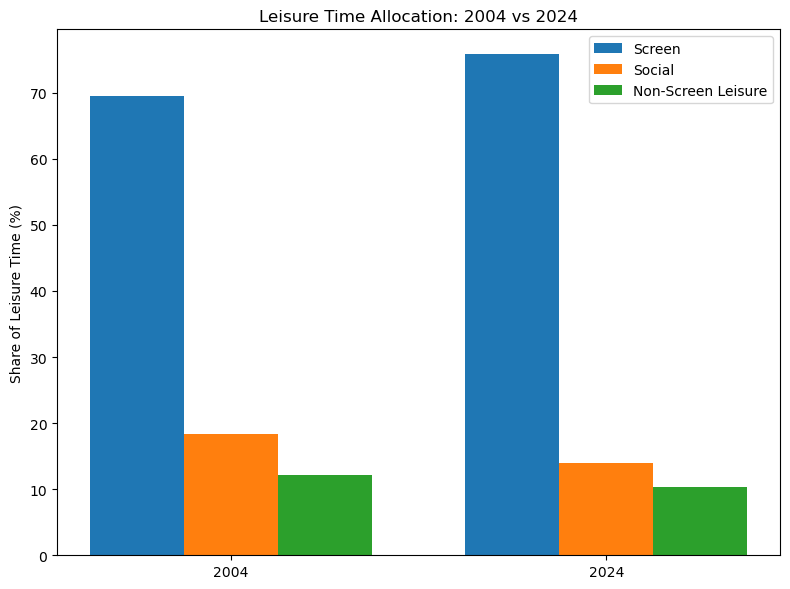

In [45]:
df_compare = df_pivot[df_pivot["year"].isin([2004, 2024])]

years = df_compare["year"].astype(str)
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(8,6))

plt.bar(x - width, df_compare["screen_leisure_pct"], width, label="Screen")
plt.bar(x, df_compare["social_leisure_pct"], width, label="Social")
plt.bar(x + width, df_compare["non_screen_leisure_pct"], width, label="Non-Screen Leisure")

plt.xticks(x, years)
plt.ylabel("Share of Leisure Time (%)")
plt.title("Leisure Time Allocation: 2004 vs 2024")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Research Question 2 Preparation

In [94]:
def classify_sports(code):
    code_str = str(code)
    
    if code_str.startswith("1301"):
        return "playing_sports"
    elif code_str.startswith("1302"):
        return "watching_sports"
    else:
        return "other"

df_full["sports_type"] = df_full["activity_code"].apply(classify_sports)

In [95]:
df_sports = df_full[df_full["sports_type"] != "other"]

In [96]:
df_sports_yearly = (
    df_sports
    .groupby(["year", "sports_type"])["minutes"]
    .sum()
    .reset_index()
)

df_sports_pivot = (
    df_sports_yearly
    .pivot(index="year", columns="sports_type", values="minutes")
    .fillna(0)
    .reset_index()
)

df_sports_pivot.head()

sports_type,year,playing_sports,watching_sports
0,2003,359688,54362
1,2004,237708,29289
2,2005,220920,30954
3,2006,220944,29191
4,2007,223222,25652


In [97]:
df_sports_pivot["sports_total"] = (
    df_sports_pivot["playing_sports"] +
    df_sports_pivot["watching_sports"]
)

df_sports_pivot["playing_share"] = (
    df_sports_pivot["playing_sports"] /
    df_sports_pivot["sports_total"]
)

df_sports_pivot["watching_share"] = (
    df_sports_pivot["watching_sports"] /
    df_sports_pivot["sports_total"]
)

df_sports_pivot["playing_pct"] = df_sports_pivot["playing_share"] * 100
df_sports_pivot["watching_pct"] = df_sports_pivot["watching_share"] * 100

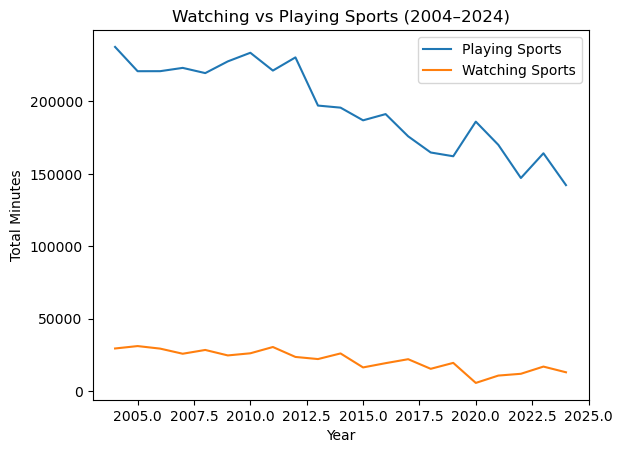

In [58]:
#Line plot
plt.figure()

plt.plot(df_sports_pivot["year"],
         df_sports_pivot["playing_sports"])

plt.plot(df_sports_pivot["year"],
         df_sports_pivot["watching_sports"])

plt.xlabel("Year")
plt.ylabel("Total Minutes")
plt.title("Watching vs Playing Sports (2004–2024)")
plt.legend(["Playing Sports", "Watching Sports"])

plt.show()

In [ ]:
#Playing sports has declined significantly over the last two decades, while watching sports has 
remained relatively stable, suggesting that increased digital access has not offset playing sports.

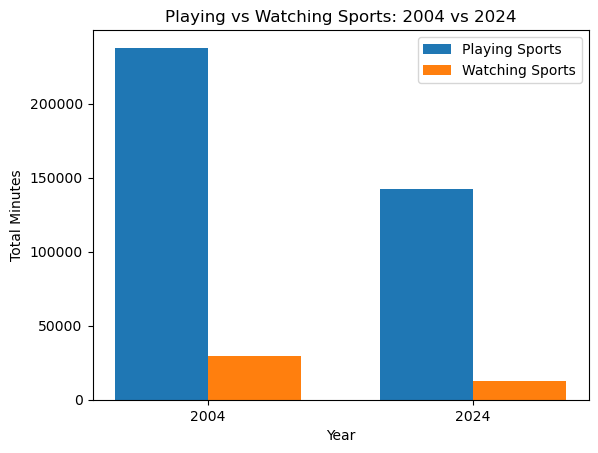

In [102]:
#Bar chart
df_compare = df_sports_pivot[df_sports_pivot["year"].isin([2004, 2024])]

years = df_compare["year"].astype(str)
x = np.arange(len(years))
width = 0.35

plt.figure()

plt.bar(x - width/2, df_compare["playing_sports"], width, label="Playing Sports")
plt.bar(x + width/2, df_compare["watching_sports"], width, label="Watching Sports")

plt.xticks(x, years)
plt.xlabel("Year")
plt.ylabel("Total Minutes")
plt.title("Playing vs Watching Sports: 2004 vs 2024")
plt.legend()

plt.show()

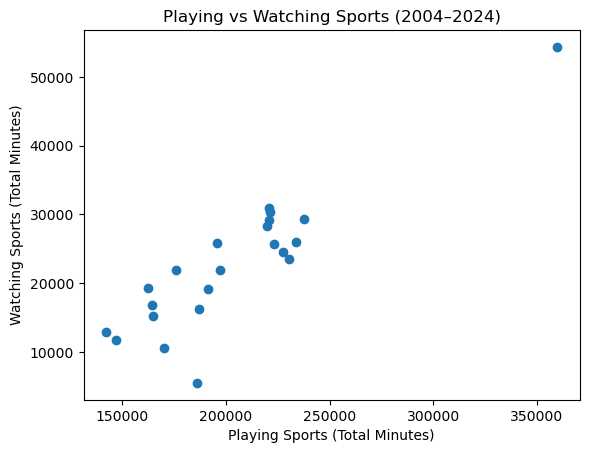

In [101]:
#Scatter plot:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df_sports_pivot["playing_sports"],
            df_sports_pivot["watching_sports"])

plt.xlabel("Playing Sports (Total Minutes)")
plt.ylabel("Watching Sports (Total Minutes)")
plt.title("Playing vs Watching Sports (2004–2024)")

plt.show()

In [103]:
#Kernel Restart
import pandas as pd
import numpy as np

df = pd.read_csv("atus_00002.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
   YEAR  ACTIVITY  DURATION
0  2003    130124        60
1  2003     10201        30
2  2003     10101       600
3  2003    120303       150
4  2003    110101         5


In [34]:
df = df.rename(columns={
    "YEAR": "year",
    "ACTIVITY": "activity_code",
    "DURATION": "minutes"
})

print("Columns after renaming:")
print(df.columns)

Columns after renaming:
Index(['year', 'activity_code', 'minutes'], dtype='object')


In [108]:
def classify_activity(code):

    code_str = str(code)

    if code in [120303, 120304, 120307, 120308] or code_str.startswith("1601"):
        return "screen"

    elif code in [120101, 120201, 120202]:
        return "social"

    elif code in [120305, 120306, 120309, 120310, 120311, 120312, 120313]:
        return "non_screen_leisure"

    else:
        return "other"


df["activity_type"] = df["activity_code"].apply(classify_activity)

print("Activity types created:")
print(df.head())

Activity types created:
   year  activity_code  minutes activity_type
0  2003         130124       60         other
1  2003          10201       30         other
2  2003          10101      600         other
3  2003         120303      150        screen
4  2003         110101        5         other


In [ ]:
#Project Assignment 5

In [111]:
#Research Question 1: Data Aggregation by year and activity type
df_yearly = (
    df
    .groupby(["year", "activity_type"])["minutes"]
    .sum()
    .reset_index()
)

print("Aggregated dataset:")
print(df_yearly.head(12))

Aggregated dataset:
    year       activity_type   minutes
0   2003  non_screen_leisure    621450
1   2003               other  24347697
2   2003              screen   3784673
3   2003              social   1082980
4   2004  non_screen_leisure    466860
5   2004               other  16282349
6   2004              screen   2665267
7   2004              social    706644
8   2005  non_screen_leisure    407468
9   2005               other  15320680
10  2005              screen   2394252
11  2005              social    652320


In [114]:
#Group Operations
df = df.rename(columns={
    "YEAR": "year",
    "ACTIVITY": "activity_code",
    "DURATION": "minutes"
})

print("Rows per year:")
print(df_yearly.groupby("year").size())

Rows per year:
year
2003    4
2004    4
2005    4
2006    4
2007    4
2008    4
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    4
2024    4
dtype: int64


In [115]:
avg_activity_time = (
    df
    .groupby("activity_type")["minutes"]
    .mean()
    .reset_index()
)

print("Average minutes per activity type:")
print(avg_activity_time)

Average minutes per activity type:
        activity_type     minutes
0  non_screen_leisure   68.525556
1               other   71.158116
2              screen  102.688546
3              social   78.631615


In [116]:
total_activity_time = (
    df
    .groupby("activity_type")["minutes"]
    .sum()
    .reset_index()
)

print("Total minutes per activity type:")
print(total_activity_time)

Total minutes per activity type:
        activity_type    minutes
0  non_screen_leisure    7151190
1               other  293263162
2              screen   51968414
3              social   11660754


In [136]:
#Grouping Data 
grouped_data = df.groupby(["year", "activity_type"])["minutes"].sum()

print(grouped_data.head(12))

year  activity_type     
2003  non_screen_leisure      621450
      other                 24347697
      screen                 3784673
      social                 1082980
2004  non_screen_leisure      466860
      other                 16282349
      screen                 2665267
      social                  706644
2005  non_screen_leisure      407468
      other                 15320680
      screen                 2394252
      social                  652320
Name: minutes, dtype: int64


In [132]:
#Pivot Tables 
grouped_data = grouped_data.reset_index()

print(grouped_data.head())

   year       activity_type   minutes
0  2003  non_screen_leisure    621450
1  2003               other  24347697
2  2003              screen   3784673
3  2003              social   1082980
4  2004  non_screen_leisure    466860


In [133]:
pivot_table = grouped_data.pivot(
    index="year",
    columns="activity_type",
    values="minutes"
)

print(pivot_table.head())

activity_type  non_screen_leisure     other   screen   social
year                                                         
2003                       621450  24347697  3784673  1082980
2004                       466860  16282349  2665267   706644
2005                       407468  15320680  2394252   652320
2006                       389402  15169390  2435066   644062
2007                       348594  14365644  2327565   595317


In [130]:
pivot_table = pivot_table.fillna(0)
print(pivot_table.head())

activity_type  non_screen_leisure     other   screen   social
year                                                         
2003                       621450  24347697  3784673  1082980
2004                       466860  16282349  2665267   706644
2005                       407468  15320680  2394252   652320
2006                       389402  15169390  2435066   644062
2007                       348594  14365644  2327565   595317


In [134]:
#Cross-Tabulation
cross_tab = pd.crosstab(df["year"], df["activity_type"])

print(cross_tab.head())

activity_type  non_screen_leisure   other  screen  social
year                                                     
2003                         9616  350859   38454   13682
2004                         7212  235067   27479    9284
2005                         6375  222612   25257    8855
2006                         6244  222222   25955    8865
2007                         5433  201634   23672    7676


In [154]:
cross_tab_prop = pd.crosstab(df["year"], df["activity_type"], normalize="index")

print(cross_tab_prop.head())

activity_type  non_screen_leisure     other    screen    social
year                                                           
2003                     0.023305  0.850338  0.093197  0.033160
2004                     0.025846  0.842407  0.098476  0.033271
2005                     0.024230  0.846115  0.095998  0.033657
2006                     0.023716  0.844033  0.098581  0.033671
2007                     0.022788  0.845727  0.099289  0.032196


In [140]:
#Research Question 2: Data Aggregation by year and sports type
def classify_sports(code):

    code_str = str(code)

    if code_str.startswith("1301"):
        return "playing_sports"

    elif code_str.startswith("1302"):
        return "watching_sports"

    else:
        return "other"


df["sports_type"] = df["activity_code"].apply(classify_sports)
df_sports = df[df["sports_type"] != "other"]

In [142]:
sports_yearly = (
    df_sports
    .groupby(["year","sports_type"])["minutes"]
    .sum()
    .reset_index()
)

print(sports_yearly.head())

   year      sports_type  minutes
0  2003   playing_sports   359688
1  2003  watching_sports    54362
2  2004   playing_sports   237708
3  2004  watching_sports    29289
4  2005   playing_sports   220920


In [143]:
#Group Operations
sports_grouped = df_sports.groupby(["year", "sports_type"])["minutes"].sum()
print(sports_grouped.head())

year  sports_type    
2003  playing_sports     359688
      watching_sports     54362
2004  playing_sports     237708
      watching_sports     29289
2005  playing_sports     220920
Name: minutes, dtype: int64


In [144]:
#Grouping Data
sports_group = (
    df_sports
    .groupby("sports_type")["minutes"]
    .mean()
    .reset_index()
)

print(sports_group)

       sports_type     minutes
0   playing_sports   73.267839
1  watching_sports  152.135976


In [146]:
sports_total = (
    df_sports
    .groupby("sports_type")["minutes"]
    .sum()
    .reset_index()
)

print(sports_total)

       sports_type  minutes
0   playing_sports  4478863
1  watching_sports   499006


In [148]:
#Pivot Tables
sports_pivot = sports_year_group.pivot(
    index="year",
    columns="sports_type",
    values="minutes"
)

print(sports_pivot.head())

sports_type  playing_sports  watching_sports
year                                        
2003                 359688            54362
2004                 237708            29289
2005                 220920            30954
2006                 220944            29191
2007                 223222            25652


In [149]:
sports_pivot = sports_pivot.fillna(0)
print(sports_pivot.head())

sports_type  playing_sports  watching_sports
year                                        
2003                 359688            54362
2004                 237708            29289
2005                 220920            30954
2006                 220944            29191
2007                 223222            25652


In [155]:
#Cross-Tabulation
sports_crosstab = pd.crosstab(df_sports["year"], df_sports["sports_type"])

print(sports_crosstab.head())

sports_type  playing_sports  watching_sports
year                                        
2003                   4582              369
2004                   3082              195
2005                   2936              212
2006                   2845              188
2007                   2825              158


In [152]:
sports_crosstab_prop = pd.crosstab(
    df_sports["year"],
    df_sports["sports_type"],
    normalize="index"
)

print(sports_crosstab_prop.head())

sports_type  playing_sports  watching_sports
year                                        
2003               0.925470         0.074530
2004               0.940494         0.059506
2005               0.932656         0.067344
2006               0.938015         0.061985
2007               0.947033         0.052967


In [ ]:
#Project Assignment 6

In [173]:
#Average Minutes per activity type per year
avg_minutes_year = (
    df.groupby(["year", "activity_type"])["minutes"]
    .mean()
    .reset_index()
)
print(avg_minutes_year)

    year       activity_type     minutes
0   2003  non_screen_leisure   64.626664
1   2003               other   69.394535
2   2003              screen   98.420788
3   2003              social   79.153633
4   2004  non_screen_leisure   64.733777
..   ...                 ...         ...
83  2023              social   88.403907
84  2024  non_screen_leisure   81.088693
85  2024               other   74.713835
86  2024              screen  110.913083
87  2024              social   88.951710

[88 rows x 3 columns]


In [172]:
#Pivot of average table
avg_pivot = avg_minutes_year.pivot(
    index="year",
    columns="activity_type",
    values="minutes"
)
print(avg_pivot)

activity_type  non_screen_leisure      other      screen     social
year                                                               
2003                    64.626664  69.394535   98.420788  79.153633
2004                    64.733777  69.266843   96.992867  76.114175
2005                    63.916549  68.822346   94.795581  73.666855
2006                    62.364190  68.262323   93.818763  72.652228
2007                    64.162341  71.246139   98.325659  77.555628
2008                    66.230686  69.094761   98.433321  75.342543
2009                    65.254621  69.305789   97.991004  74.089812
2010                    68.310879  70.889030  101.867484  79.020041
2011                    70.604630  73.060015  105.332647  83.602387
2012                    72.712759  73.793285  106.815634  84.490798
2013                    71.447612  72.359652  105.097132  81.469321
2014                    67.910998  71.219424  103.503520  77.850171
2015                    67.785516  69.902482  10

In [171]:
#Correlation
correlation = avg_pivot.corr()
print(avg_pivot[["screen","social","non_screen_leisure"]].corr())

activity_type         screen    social  non_screen_leisure
activity_type                                             
screen              1.000000  0.874685            0.945313
social              0.874685  1.000000            0.865436
non_screen_leisure  0.945313  0.865436            1.000000


In [163]:
#Simple Regression
import statsmodels.api as sm

X = avg_pivot["screen"]
y = avg_pivot["social"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 social   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     65.13
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.02e-07
Time:                        23:58:06   Log-Likelihood:                -50.699
No. Observations:                  22   AIC:                             105.4
Df Residuals:                      20   BIC:                             107.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2770      9.854      0.028      0.9

In [ ]:
#Second Research question

In [174]:
#Average minutes per year
sports_avg = (
    df_sports.groupby(["year","sports_type"])["minutes"]
    .mean()
    .reset_index()
)
print(sports_avg)

    year      sports_type     minutes
0   2003   playing_sports   78.500218
1   2003  watching_sports  147.322493
2   2004   playing_sports   77.127839
3   2004  watching_sports  150.200000
4   2005   playing_sports   75.245232
5   2005  watching_sports  146.009434
6   2006   playing_sports   77.660457
7   2006  watching_sports  155.271277
8   2007   playing_sports   79.016637
9   2007  watching_sports  162.354430
10  2008   playing_sports   75.313100
11  2008  watching_sports  167.284024
12  2009   playing_sports   76.258540
13  2009  watching_sports  149.335366
14  2010   playing_sports   79.425561
15  2010  watching_sports  139.596774
16  2011   playing_sports   80.116178
17  2011  watching_sports  157.838542
18  2012   playing_sports   81.758425
19  2012  watching_sports  155.231788
20  2013   playing_sports   76.809895
21  2013  watching_sports  144.559211
22  2014   playing_sports   71.385850
23  2014  watching_sports  163.708861
24  2015   playing_sports   66.563190
25  2015  wa

In [175]:
#Pivot table
sports_avg_pivot = sports_avg.pivot(
    index="year",
    columns="sports_type",
    values="minutes"
)
print(sports_avg_pivot)

sports_type  playing_sports  watching_sports
year                                        
2003              78.500218       147.322493
2004              77.127839       150.200000
2005              75.245232       146.009434
2006              77.660457       155.271277
2007              79.016637       162.354430
2008              75.313100       167.284024
2009              76.258540       149.335366
2010              79.425561       139.596774
2011              80.116178       157.838542
2012              81.758425       155.231788
2013              76.809895       144.559211
2014              71.385850       163.708861
2015              66.563190       142.052632
2016              70.400810       143.939850
2017              66.991241       145.860000
2018              67.518852       143.745283
2019              66.698067       157.186992
2020              70.746768       124.659091
2021              64.670217       146.722222
2022              68.137564       173.470588
2023      

In [170]:
#Correlation
sports_pivot[["playing_sports","watching_sports"]].corr()

sports_type,playing_sports,watching_sports
sports_type,,
playing_sports,1.000000,0.899316
watching_sports,0.899316,1.000000
